### OASIS UNet Reconstruction

In this experiment, we utilize UNet to investigate whether the Gs transformed images are invertible to their raw format. We are testing the inversion quality under two aspects:
- Intensity Level Reconstruction - How similar are the inverted image and the raw version (non-gs transformed or inverted) of the same image in terms of intensity and structuraly. we used SSIM and PSNR for these comparison
- Functionality Level Reconstruction - Regardless of how well the intensity level reconstructions are performed, whether these inverted images are passing the re-identification test. In other words, whether the inverted iamges still carry patient identifiers that could be exploited. 
    - To test this we are using the Re-Identification with PID models we trained and evaluated on the Notebook *03_OASIS_reid_PIDs*. We use same train, test and validation datasets so the reidentification scores can be directly compared among each other and with their raw corresponders.

### Imports and Functions

In [1]:
import os, pickle, random, gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

# ------------------
# CONFIG & PATHS (CLEAN)
# ------------------
REID_DATA_ROOT = Path("./data/oasis/processed/reid")     # train/val/test pkls live here
UNET_ROOT      = Path("./data/oasis/processed/unet")    # allowed UNet cache/artifacts here
UNET_ROOT.mkdir(parents=True, exist_ok=True)

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_SIZE = (224, 224)  # (W, H) for PIL; we keep oracle conventions

# Output Paths (All in ./data/oasis/processed/unet/)
X_TENSOR_OUT = UNET_ROOT / "X_raw_tensor.pt"
SUBJ_OUT     = UNET_ROOT / "subject_ids.pt"
META_OUT     = UNET_ROOT / "meta_subsampled.csv"

print(f"[INFO] Initializing U-Net Workspace: {UNET_ROOT}")

# ------------------------------------------------------------
# 1) LOAD RE-ID PICKLES (SOURCE OF TRUTH)
# ------------------------------------------------------------
def load_reid_pickle(name: str):
    path = REID_DATA_ROOT / f"{name}.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    print(f"[LOAD] {name}.pkl: {len(data)} samples -> {path}")
    return data

train_data = load_reid_pickle("train")
val_data   = load_reid_pickle("val")
test_data  = load_reid_pickle("test")

# Oracle cell concatenates all three here (we keep it for parity with the pasted cell)
full_pool = train_data + val_data + test_data
n_train, n_val, n_test = len(train_data), len(val_data), len(test_data)
print(f"[AUDIT] full_pool = train({n_train}) + val({n_val}) + test({n_test}) = {len(full_pool)}")

# ------------------------------------------------------------
# 2) EXTRACT IMAGES & METADATA (SAFE: normalize/resize if needed)
# ------------------------------------------------------------
X = np.zeros((len(full_pool), 1, IMG_SIZE[1], IMG_SIZE[0]), dtype=np.float32)
meta_rows = []

print(f"[INFO] Preprocessing {len(full_pool)} samples...")

for i, item in enumerate(full_pool):
    img_arr = item["image"]

    # Convert to numpy float32
    if isinstance(img_arr, torch.Tensor):
        img_arr = img_arr.detach().cpu().numpy()
    img_arr = np.asarray(img_arr)

    # If image is (1,H,W) or (H,W,1), squeeze to (H,W) before PIL ops
    if img_arr.ndim == 3:
        if img_arr.shape[0] == 1:
            img_arr = img_arr[0]
        elif img_arr.shape[-1] == 1:
            img_arr = img_arr[..., 0]

    img_arr = img_arr.astype(np.float32)

    # Ensure 0-1 range (oracle behavior)
    if np.nanmax(img_arr) > 1.0:
        img_arr = img_arr / 255.0

    # Ensure size (oracle behavior)
    # Note: IMG_SIZE is (W,H) but img_arr.shape is (H,W)
    if tuple(img_arr.shape) != (IMG_SIZE[1], IMG_SIZE[0]):
        # PIL expects uint8 or float; if float in [0,1], convert to uint8 for stable resize
        pil_in = (img_arr * 255.0).clip(0, 255).astype(np.uint8)
        img_pil = Image.fromarray(pil_in)
        img_pil = img_pil.resize(IMG_SIZE, resample=Image.BILINEAR)
        img_arr = np.asarray(img_pil).astype(np.float32) / 255.0

    X[i, 0] = img_arr

    sid = str(item.get("subject_id", item.get("reid_label", "Unknown")))
    slice_idx = int(item.get("slice_index", -1))

    orig_split = "train" if i < n_train else ("val" if i < n_train + n_val else "test")
    meta_rows.append({
        "index": i,
        "subject_id": sid,
        "slice_num": slice_idx,
        "orig_split": orig_split,
    })

X_raw = torch.from_numpy(X).float()
df_meta = pd.DataFrame(meta_rows)

# ------------------------------------------------------------
# 3) SAVE ARTIFACTS (UNET CACHE ALLOWED HERE)
# ------------------------------------------------------------
torch.save(X_raw, X_TENSOR_OUT)
torch.save(df_meta["subject_id"].tolist(), SUBJ_OUT)
df_meta.to_csv(META_OUT, index=False)

print("\n" + "="*80)
print("TENSOR REPORT (PICKLE-BASED)")
print("="*80)
print(f"X_raw shape: {tuple(X_raw.shape)}")
print(f"Total Subjects: {df_meta['subject_id'].nunique()}")
print(f"Range: min={X_raw.min():.4f}, max={X_raw.max():.4f}")
print(f"Mean:  {X_raw.mean():.4f}")
print("="*80)

# Cleanup (oracle-equivalent)
del train_data, val_data, test_data, full_pool, X
gc.collect()

[INFO] Initializing U-Net Workspace: data/oasis/processed/unet
[LOAD] train.pkl: 1388 samples -> data/oasis/processed/reid/train.pkl
[LOAD] val.pkl: 347 samples -> data/oasis/processed/reid/val.pkl
[LOAD] test.pkl: 1041 samples -> data/oasis/processed/reid/test.pkl
[AUDIT] full_pool = train(1388) + val(347) + test(1041) = 2776
[INFO] Preprocessing 2776 samples...

TENSOR REPORT (PICKLE-BASED)
X_raw shape: (2776, 1, 224, 224)
Total Subjects: 347
Range: min=0.0000, max=1.0000
Mean:  0.1919


0

In [2]:
import json, random, gc
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------
# CONFIG & PATHS (CLEAN)
# ------------------
UNET_ROOT = Path("./data/oasis/processed/unet")
META_CSV  = UNET_ROOT / "meta_subsampled.csv"
SPLIT_JSON = UNET_ROOT / "splits_subject_level.json"

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)

# Reserved specifically for Plan B functionality testing (excluded from U-Net training)
RESERVED_SLICES = [122, 130, 138]

# Target ratios for SUBJECT-level partitioning
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.10
TEST_FRAC  = 0.20

# ------------------------------------------------------------
# 1) LOAD REID-ALIGNED METADATA
# ------------------------------------------------------------
df = pd.read_csv(META_CSV)
subjects = sorted(df["subject_id"].unique().tolist())

# ------------------------------------------------------------
# 2) PERFORM SUBJECT-LEVEL SPLIT (REPRODUCIBLE)
# ------------------------------------------------------------
rng = random.Random(SEED)
subj_list = subjects[:]
rng.shuffle(subj_list)

n = len(subj_list)
n_tr = int(round(n * TRAIN_FRAC))
n_va = int(round(n * VAL_FRAC))

train_subj = subj_list[:n_tr]
val_subj   = subj_list[n_tr:n_tr + n_va]
test_subj  = subj_list[n_tr + n_va:]

# ------------------------------------------------------------
# 3) ASSIGN SLICE-LEVEL INDICES (LEAKAGE GUARD)
# ------------------------------------------------------------

# Test: ONLY reserved slices from test subjects
idx_test = df.index[
    df["subject_id"].isin(test_subj) &
    df["slice_num"].isin(RESERVED_SLICES)
].to_numpy()

# Train / Val: ALL non-reserved slices from respective subjects
idx_train = df.index[
    df["subject_id"].isin(train_subj) &
    ~df["slice_num"].isin(RESERVED_SLICES)
].to_numpy()

idx_val = df.index[
    df["subject_id"].isin(val_subj) &
    ~df["slice_num"].isin(RESERVED_SLICES)
].to_numpy()

# ------------------------------------------------------------
# 4) SANITY CHECKS & SAVE
# ------------------------------------------------------------
assert set(idx_train).isdisjoint(set(idx_test)), "LEAKAGE: Train and Test indices overlap!"
assert set(idx_val).isdisjoint(set(idx_test)), "LEAKAGE: Val and Test indices overlap!"
assert df.iloc[idx_train]["slice_num"].isin(RESERVED_SLICES).sum() == 0, \
    "LEAKAGE: Reserved slices found in Train!"

splits = {
    "seed": SEED,
    "subjects": {
        "train": train_subj,
        "val": val_subj,
        "test": test_subj,
    },
    "indices": {
        "train": idx_train.tolist(),
        "val": idx_val.tolist(),
        "test": idx_test.tolist(),
    },
}

with open(SPLIT_JSON, "w") as f:
    json.dump(splits, f, indent=2)

print("\n" + "="*80)
print("SPLIT REPORT (IDENTITY-ALIGNED)")
print("="*80)
print(f"Total Slices Available: {len(df)}")
print(f"Train (Non-Reserved):  {len(idx_train)} slices | {len(train_subj)} subjects")
print(f"Val   (Non-Reserved):  {len(idx_val)} slices | {len(val_subj)} subjects")
print(f"Test  (GOLD RESERVED): {len(idx_test)} slices | {len(test_subj)} subjects")
print("="*80)

gc.collect()


SPLIT REPORT (IDENTITY-ALIGNED)
Total Slices Available: 2776
Train (Non-Reserved):  1215 slices | 243 subjects
Val   (Non-Reserved):  175 slices | 35 subjects
Test  (GOLD RESERVED): 207 slices | 69 subjects


33

In [3]:
import json, gc
from pathlib import Path

import pandas as pd
import torch

# ------------------
# CONFIG & PATHS (CLEAN)
# ------------------
UNET_ROOT = Path("./data/oasis/processed/unet")
X_RAW_PATH = UNET_ROOT / "X_raw_tensor.pt"
META_CSV   = UNET_ROOT / "meta_subsampled.csv"
SPLIT_JSON = UNET_ROOT / "splits_subject_level.json"

# ------------------------------------------------------------
# 1) LOAD DATA AND STRICT SPLIT INDICES
# ------------------------------------------------------------
# Load to CPU first to preserve GPU VRAM for U-Net training
x_raw_all = torch.load(X_RAW_PATH, map_location="cpu")
df = pd.read_csv(META_CSV)

with open(SPLIT_JSON, "r") as f:
    splits = json.load(f)

idx_tr = splits["indices"]["train"]
idx_va = splits["indices"]["val"]
idx_te = splits["indices"]["test"]

# ------------------------------------------------------------
# 2) ALIGNMENT SANITY CHECK
# ------------------------------------------------------------
assert len(df) == x_raw_all.shape[0], \
    "Metadata and tensor alignment error!"

# ------------------------------------------------------------
# 3) EXTRACT RAW TENSORS PER SPLIT
# ------------------------------------------------------------
# clone() ensures independent storage (oracle behavior)
x_train_raw = x_raw_all[idx_tr].clone()
x_val_raw   = x_raw_all[idx_va].clone()
x_test_raw  = x_raw_all[idx_te].clone()

# ------------------------------------------------------------
# 4) EXTRACT CORRESPONDING META FOR TRACKING
# ------------------------------------------------------------
df_train = df.iloc[idx_tr].copy()
df_val   = df.iloc[idx_va].copy()
df_test  = df.iloc[idx_te].copy()

# ------------------------------------------------------------
# 5) MEMORY CLEARANCE (CRITICAL)
# ------------------------------------------------------------
del x_raw_all
gc.collect()

print("\n" + "="*80)
print("SPLIT TENSOR REPORT")
print("="*80)
print(
    f"X_train_raw: {tuple(x_train_raw.shape)} | "
    f"Range: [{x_train_raw.min():.3f}, {x_train_raw.max():.3f}]"
)
print(
    f"X_val_raw:   {tuple(x_val_raw.shape)} | "
    f"Range: [{x_val_raw.min():.3f}, {x_val_raw.max():.3f}]"
)
print(
    f"X_test_raw:  {tuple(x_test_raw.shape)} | "
    f"Range: [{x_test_raw.min():.3f}, {x_test_raw.max():.3f}]"
)
print("-" * 80)

# ------------------------------------------------------------
# 6) DATA LEAKAGE VERIFICATION
# ------------------------------------------------------------
RESERVED = [122, 130, 138]

tr_reserved_count = df_train["slice_num"].isin(RESERVED).sum()
te_reserved_count = df_test["slice_num"].isin(RESERVED).sum()

print(f"[VERIFY] Reserved slices in Train: {tr_reserved_count} (Must be 0)")
print(f"[VERIFY] Reserved slices in Test:  {te_reserved_count} (Must be {len(idx_te)})")

if tr_reserved_count == 0:
    print("✅ OK: Data leakage check passed. Training set is identity-clean.")
else:
    raise ValueError(
        "CRITICAL: Leakage detected! Reserved slices found in training set."
    )
print("=" * 80)



SPLIT TENSOR REPORT
X_train_raw: (1215, 1, 224, 224) | Range: [0.000, 1.000]
X_val_raw:   (175, 1, 224, 224) | Range: [0.000, 1.000]
X_test_raw:  (207, 1, 224, 224) | Range: [0.000, 1.000]
--------------------------------------------------------------------------------
[VERIFY] Reserved slices in Train: 0 (Must be 0)
[VERIFY] Reserved slices in Test:  207 (Must be 207)
✅ OK: Data leakage check passed. Training set is identity-clean.


In [4]:
import time, gc
from pathlib import Path

import numpy as np
import torch
from gs_functions import GS_batch_image

# ------------------
# CONFIG & CACHING (CLEAN, ORACLE-EQUIVALENT)
# ------------------
UNET_ROOT = Path("./data/oasis/processed/unet")
GS_CACHE  = UNET_ROOT / "gs_cache"
GS_CACHE.mkdir(parents=True, exist_ok=True)

# GS Parameters (MUST match oracle exactly)
BATCH_GS = 200
ITE = 50
P_LIST = [0.0, 0.5]

def _cache_path(split_name: str, p: float) -> Path:
    p_tag = f"p{int(p * 100):02d}"
    # Split-aware cache to prevent leakage
    return GS_CACHE / f"gs_{split_name}_{p_tag}.pt"

@torch.no_grad()
def build_or_load_gs(x_raw_split: torch.Tensor, split_name: str, p: float) -> torch.Tensor:
    out_path = _cache_path(split_name, p)

    # Oracle behavior: reuse cached GS outputs if present
    if out_path.exists():
        y = torch.load(out_path, map_location="cpu")
        print(
            f"[CACHE] {split_name} p={p} -> Loaded {out_path.name} | "
            f"Shape: {tuple(y.shape)}"
        )
        return y

    # GS expects (N, H, W)
    x_in = x_raw_split.squeeze(1).contiguous()
    x_np = x_in.cpu().numpy().astype(np.float32)

    print(f"[GS] Processing {split_name} p={p} for {len(x_np)} slices...")
    t0 = time.time()

    # Oracle GS execution (stochasticity preserved)
    y_np = GS_batch_image(
        x_np,
        batch_size=BATCH_GS,
        ite=ITE,
        maskP=float(p),
    )

    dt = time.time() - t0

    # Back to torch: (N, 1, 224, 224)
    y = torch.from_numpy(y_np).float().unsqueeze(1)
    torch.save(y, out_path)

    print(
        f"[GS] Completed in {dt / 60:.2f} min. "
        f"Range: [{y.min():.4f}, {y.max():.4f}]"
    )

    # Explicit cleanup (oracle behavior)
    del x_np, y_np
    gc.collect()

    return y

# ------------------
# EXECUTION
# ------------------
# Store GS outputs per split and p for downstream UNet usage
gs = {"train": {}, "val": {}, "test": {}}

for p in P_LIST:
    gs["train"][p] = build_or_load_gs(x_train_raw, "train", p)
    gs["val"][p]   = build_or_load_gs(x_val_raw,   "val",   p)
    gs["test"][p]  = build_or_load_gs(x_test_raw,  "test",  p)

# ------------------
# STATUS REPORT
# ------------------
print("\n" + "=" * 80)
print("GS TENSOR STATUS")
print("=" * 80)
for split_name in gs:
    for p_val in gs[split_name]:
        print(
            f"Split: {split_name:5} | p: {p_val} | "
            f"Shape: {tuple(gs[split_name][p_val].shape)}"
        )
print("=" * 80)

# Cleanup (host RAM)
gc.collect()


[GS] Processing train p=0.0 for 1215 slices...
Batch 6 of 6 (full batch) completed...
Remaining data batch completed (size: 15)...[GS] Completed in 0.33 min. Range: [0.0001, 6.2075]
[GS] Processing val p=0.0 for 175 slices...

Remaining data batch completed (size: 175)...[GS] Completed in 0.04 min. Range: [0.0001, 5.7731]
[GS] Processing test p=0.0 for 207 slices...
Batch 1 of 1 (full batch) completed...
Remaining data batch completed (size: 7)...[GS] Completed in 0.05 min. Range: [0.0000, 5.6256]
[GS] Processing train p=0.5 for 1215 slices...
Batch 6 of 6 (full batch) completed...
Remaining data batch completed (size: 15)...[GS] Completed in 0.32 min. Range: [0.0000, 3.6306]
[GS] Processing val p=0.5 for 175 slices...

Remaining data batch completed (size: 175)...[GS] Completed in 0.04 min. Range: [0.0005, 3.6975]
[GS] Processing test p=0.5 for 207 slices...
Batch 1 of 1 (full batch) completed...
Remaining data batch completed (size: 7)...[GS] Completed in 0.05 min. Range: [0.0001, 3.

0

In [5]:
import math, random, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -----------------------
# Determinism & Device
# -----------------------
SEED = 1337

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Training on: {DEVICE}")

# -----------------------
# Metrics (SSIM & PSNR)
# -----------------------
def _gaussian_window(window_size=11, sigma=1.5, channels=1, device="cpu"):
    coords = torch.arange(window_size, device=device).float() - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w = (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)
    return w.repeat(channels, 1, 1, 1)

def ssim_torch(x, y, window_size=11, sigma=1.5, data_range=1.0, eps=1e-6):
    """Structural Similarity Index (SSIM)."""
    x, y = x.float(), y.float()
    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    ch = x.shape[1]
    w = _gaussian_window(window_size, sigma, ch, device=x.device)

    mu_x = F.conv2d(x, w, padding=window_size // 2, groups=ch)
    mu_y = F.conv2d(y, w, padding=window_size // 2, groups=ch)

    sigma_x2 = F.conv2d(x * x, w, padding=window_size // 2, groups=ch) - mu_x ** 2
    sigma_y2 = F.conv2d(y * y, w, padding=window_size // 2, groups=ch) - mu_y ** 2
    sigma_xy = F.conv2d(x * y, w, padding=window_size // 2, groups=ch) - (mu_x * mu_y)

    num = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    den = (mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x2 + sigma_y2 + C2)

    return (num / torch.clamp(den, min=eps)).mean(dim=(1, 2, 3))

def psnr_torch(x, y, data_range=1.0, eps=1e-8):
    """Peak Signal-to-Noise Ratio (PSNR)."""
    mse = F.mse_loss(x, y, reduction="none").mean(dim=(1, 2, 3))
    return 10.0 * torch.log10((data_range ** 2) / (mse + eps))

# -----------------------
# Dataset & Architecture
# -----------------------
class PairedInversionDataset(Dataset):
    def __init__(self, x_gs: torch.Tensor, x_raw: torch.Tensor):
        assert x_gs.shape[0] == x_raw.shape[0], (
            f"GS ({x_gs.shape[0]}) and Raw ({x_raw.shape[0]}) size mismatch!"
        )
        self.x = x_gs
        self.y = x_raw

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.mid  = ConvBlock(base * 4, base * 8)

        self.up3  = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)

        self.up2  = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1  = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)

        self.out  = nn.Sequential(
            nn.Conv2d(base, out_ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        m  = self.mid(F.max_pool2d(e3, 2))

        d3 = self.dec3(torch.cat([self.up3(m), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

# -----------------------
# Loss & Dataloaders
# -----------------------
def inversion_loss(x_hat, x_true, w_l1=1.0, w_ssim=0.5):
    l1 = F.l1_loss(x_hat, x_true)
    ssim_val = ssim_torch(x_hat, x_true, data_range=1.0).mean()
    return w_l1 * l1 + w_ssim * (1.0 - ssim_val), {
        "l1": l1.item(),
        "ssim": ssim_val.item(),
    }

BATCH_SIZE = 16
dataloaders = {}

for p in P_LIST:
    ds_tr = PairedInversionDataset(gs["train"][p], x_train_raw)
    ds_va = PairedInversionDataset(gs["val"][p],   x_val_raw)
    ds_te = PairedInversionDataset(gs["test"][p],  x_test_raw)

    dataloaders[p] = {
        "train": DataLoader(
            ds_tr, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=2, pin_memory=True
        ),
        "val": DataLoader(
            ds_va, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=2, pin_memory=True
        ),
        "test": DataLoader(
            ds_te, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=2, pin_memory=True
        ),
    }

    print(
        f"[OK] p={p} Loaders Ready. "
        f"Train size: {len(ds_tr)}, "
        f"Val size: {len(ds_va)}, "
        f"Test size: {len(ds_te)}"
    )

# Cleanup host RAM if possible
gc.collect()


[INFO] Training on: cuda
[OK] p=0.0 Loaders Ready. Train size: 1215, Val size: 175, Test size: 207
[OK] p=0.5 Loaders Ready. Train size: 1215, Val size: 175, Test size: 207


0

In [6]:
import json, time, gc
from pathlib import Path

import numpy as np
import torch

# -----------------------
# CONFIG & LOGGING (CLEAN)
# -----------------------
UNET_ROOT = Path("./data/oasis/processed/unet")
RUNS_DIR = UNET_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = True  # Mixed precision, oracle-equivalent

# Hyperparameters (MUST match oracle)
EPOCHS = 10
LR = 2e-4
WEIGHT_DECAY = 1e-4
P_TO_TRAIN = [0.0, 0.5]
PATIENCE = 3
W_L1 = 1.0
W_SSIM = 0.1

print(f"[INFO] DEVICE: {DEVICE} | AMP: {AMP}")
print("[INFO] Logic: Strict identity-split training (excludes slices 122, 130, 138)")

def train_one_p(p: float):
    """Executes a full UNet inversion training run for a given GS masking level."""
    p_tag = f"p{int(p * 100):02d}"
    run_dir = RUNS_DIR / f"unet_inv_oasis_RESERVED_{p_tag}"
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_best = run_dir / "best.pt"
    hist_json = run_dir / "history.json"

    # Model, Optimizer, Scaler (oracle-equivalent)
    model = UNet2D(in_ch=1, out_ch=1, base=32).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)

    best_val_loss = float("inf")
    early_stop_counter = 0
    history = []

    print("\n" + "=" * 80)
    print(f"[RUN START] GS level p={p} | Saving to: {run_dir}")
    print("=" * 80)

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        # -------------------
        # TRAIN PHASE
        # -------------------
        model.train()
        train_losses = []

        for xg, xr in dataloaders[p]["train"]:
            xg = xg.to(DEVICE)
            xr = xr.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=AMP):
                x_hat = model(xg)
                loss, _ = inversion_loss(
                    x_hat, xr, w_l1=W_L1, w_ssim=W_SSIM
                )

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss).backward()

            # Gradient clipping (oracle behavior)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            train_losses.append(loss.item())

        # -------------------
        # VALIDATION PHASE
        # -------------------
        model.eval()
        val_losses = []

        with torch.no_grad():
            for xg, xr in dataloaders[p]["val"]:
                xg = xg.to(DEVICE)
                xr = xr.to(DEVICE)

                with torch.amp.autocast(device_type="cuda", enabled=AMP):
                    x_hat = model(xg)
                    v_loss, _ = inversion_loss(
                        x_hat, xr, w_l1=W_L1, w_ssim=W_SSIM
                    )

                if torch.isfinite(v_loss):
                    val_losses.append(v_loss.item())

        avg_tr = np.mean(train_losses) if train_losses else 0.0
        avg_va = np.mean(val_losses) if val_losses else 0.0
        dt = time.time() - t0

        # -------------------
        # CHECKPOINT & EARLY STOP
        # -------------------
        if avg_va < best_val_loss - 1e-5:
            best_val_loss = avg_va
            early_stop_counter = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "p": p,
                    "epoch": epoch,
                    "val_loss": avg_va,
                },
                ckpt_best,
            )
            status = "⭐ NEW BEST"
        else:
            early_stop_counter += 1
            status = ""

        history.append(
            {"epoch": epoch, "train": avg_tr, "val": avg_va}
        )

        print(
            f"[E{epoch:02d}] Tr: {avg_tr:.4f} | "
            f"Va: {avg_va:.4f} | {status} ({dt:.1f}s)"
        )

        if early_stop_counter >= PATIENCE:
            print(f"[INFO] Early stopping triggered at epoch {epoch}")
            break

    with open(hist_json, "w") as f:
        json.dump(history, f, indent=2)

    # Cleanup for next GS level
    del model, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()

    return ckpt_best

# -----------------------
# EXECUTION
# -----------------------
trained_ckpts = {p: train_one_p(p) for p in P_TO_TRAIN}
print("\n[DONE] Training complete. Checkpoints saved.")


[INFO] DEVICE: cuda | AMP: True
[INFO] Logic: Strict identity-split training (excludes slices 122, 130, 138)

[RUN START] GS level p=0.0 | Saving to: data/oasis/processed/unet/runs/unet_inv_oasis_RESERVED_p00
[E01] Tr: 0.1072 | Va: 0.0668 | ⭐ NEW BEST (12.6s)
[E02] Tr: 0.0605 | Va: 0.0552 | ⭐ NEW BEST (11.8s)
[E03] Tr: 0.0525 | Va: 0.0521 | ⭐ NEW BEST (11.8s)
[E04] Tr: 0.0486 | Va: 0.0474 | ⭐ NEW BEST (11.8s)
[E05] Tr: 0.0465 | Va: 0.0465 | ⭐ NEW BEST (11.8s)
[E06] Tr: 0.0448 | Va: 0.0445 | ⭐ NEW BEST (11.8s)
[E07] Tr: 0.0442 | Va: 0.0420 | ⭐ NEW BEST (11.8s)
[E08] Tr: 0.0419 | Va: 0.0435 |  (11.8s)
[E09] Tr: 0.0415 | Va: 0.0406 | ⭐ NEW BEST (11.8s)
[E10] Tr: 0.0408 | Va: 0.0384 | ⭐ NEW BEST (11.8s)

[RUN START] GS level p=0.5 | Saving to: data/oasis/processed/unet/runs/unet_inv_oasis_RESERVED_p50
[E01] Tr: 0.1530 | Va: 0.1058 | ⭐ NEW BEST (11.8s)
[E02] Tr: 0.0986 | Va: 0.0894 | ⭐ NEW BEST (11.8s)
[E03] Tr: 0.0877 | Va: 0.0826 | ⭐ NEW BEST (11.8s)
[E04] Tr: 0.0821 | Va: 0.0780 | ⭐ NEW 


[EVAL RESERVED] p=0.0 | Safe Samples: 207
  SSIM: 0.7889 | PSNR: 33.44 dB | MAE: 0.017640


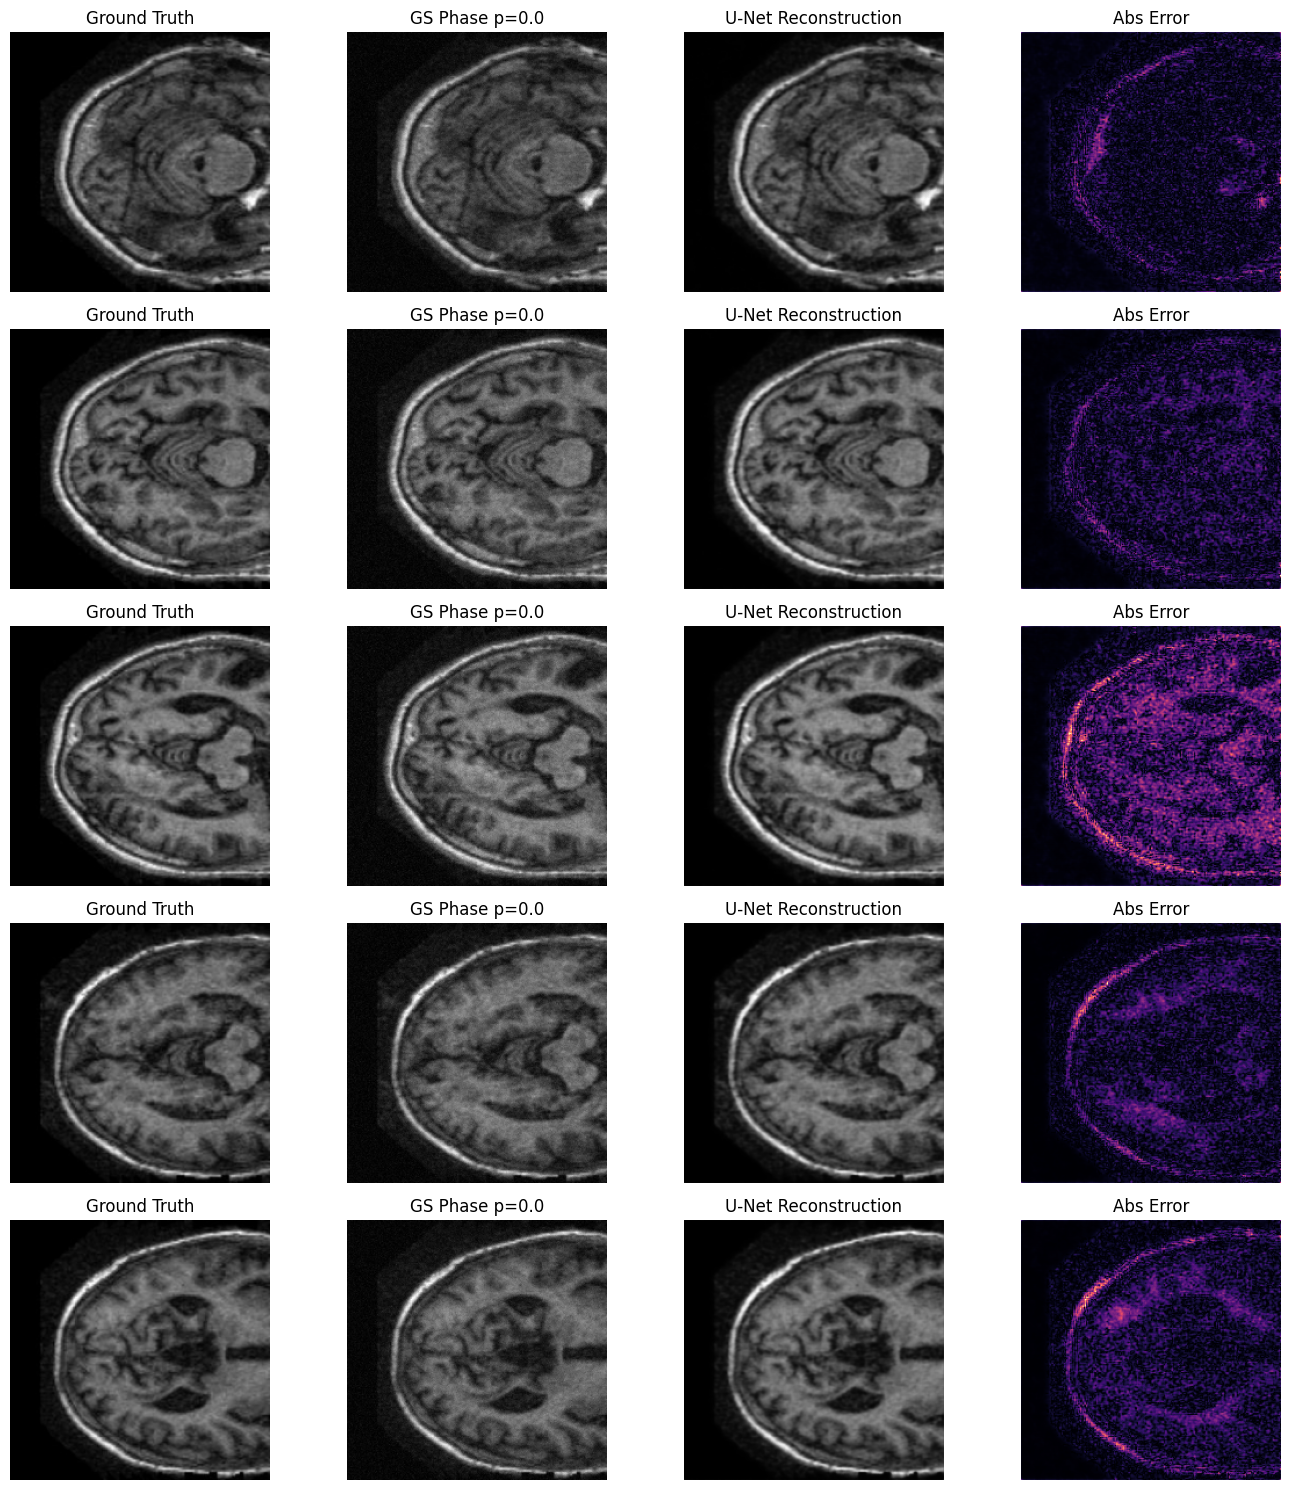


[EVAL RESERVED] p=0.5 | Safe Samples: 207
  SSIM: 0.6146 | PSNR: 26.50 dB | MAE: 0.034518


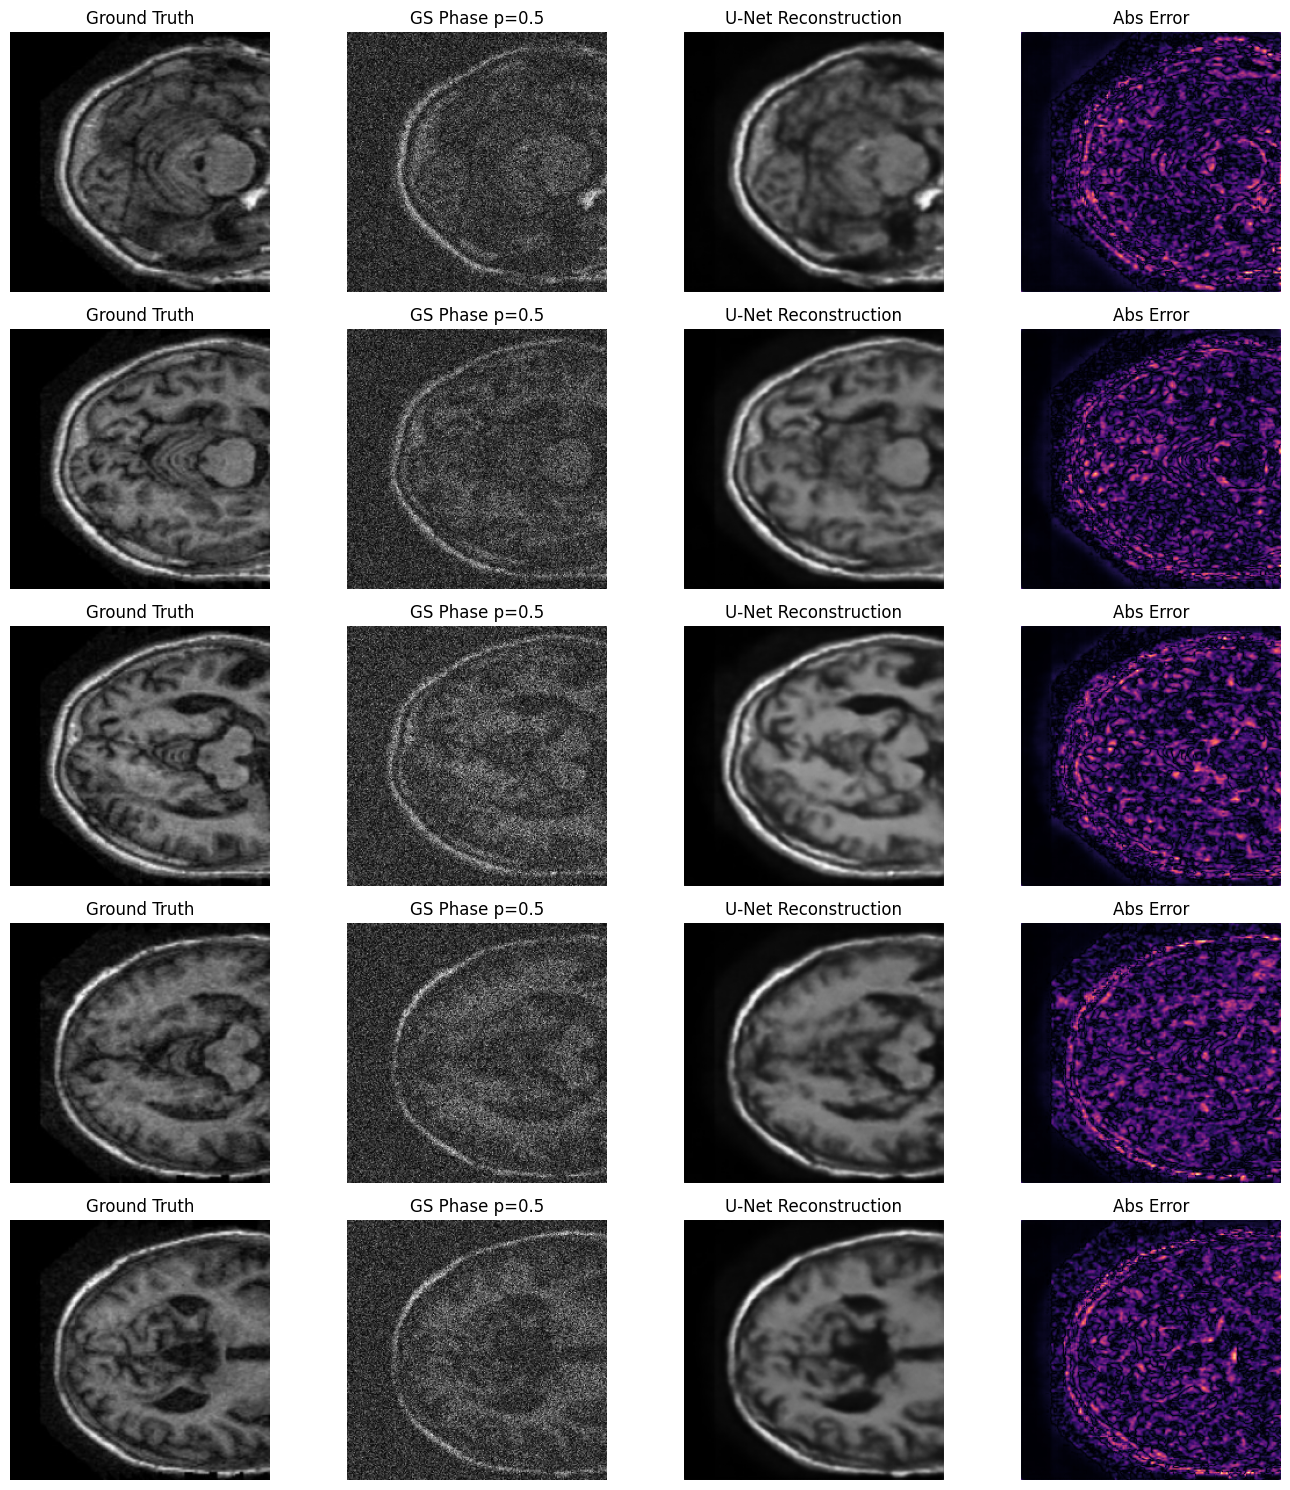


[DONE] Evaluation complete. Saved results to data/oasis/processed/unet/eval_reserved


In [7]:
import json, gc
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------
# CONFIG & PATHS (CLEAN)
# ------------------
UNET_ROOT = Path("./data/oasis/processed/unet")
RUNS_DIR  = UNET_ROOT / "runs"

EVAL_DIR = UNET_ROOT / "eval_reserved"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------
# HELPER: BATCH PREDICTION (MEMORY EFFICIENT)
# ------------------
@torch.no_grad()
def predict_in_batches(model, x, batch_size=32):
    model.eval()
    preds = []
    for i in range(0, x.shape[0], batch_size):
        xb = x[i:i + batch_size].to(DEVICE)
        yb = model(xb).detach().cpu()
        preds.append(yb)
        del xb
    return torch.cat(preds, dim=0)

# ------------------
# HELPER: CHECKPOINT LOADING
# ------------------
def get_ckpt_path(p: float) -> Path:
    p_tag = f"p{int(p * 100):02d}"
    return RUNS_DIR / f"unet_inv_oasis_RESERVED_{p_tag}" / "best.pt"

def load_trained_model(p: float) -> torch.nn.Module:
    path = get_ckpt_path(p)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    payload = torch.load(path, map_location="cpu", weights_only=False)
    model = UNet2D(in_ch=1, out_ch=1, base=32)

    # Oracle-compatible loading
    if "model_state_dict" in payload:
        model.load_state_dict(payload["model_state_dict"])
    else:
        model.load_state_dict(payload["model"])

    model.eval()
    return model

# ------------------
# HELPER: SPECTRAL METRIC
# ------------------
def fft_logmag_l2(x, y, eps=1e-8):
    """Spectral fidelity in Fourier domain (log-magnitude L2)."""
    X = torch.fft.rfft2(x.float(), norm="ortho")
    Y = torch.fft.rfft2(y.float(), norm="ortho")
    Xm = torch.log1p(torch.abs(X) + eps)
    Ym = torch.log1p(torch.abs(Y) + eps)
    return (Xm - Ym).pow(2).mean(dim=(1, 2, 3)).sqrt().cpu()

# ------------------
# EVALUATION LOOP (RESERVED / IDENTITY-LOCKED)
# ------------------
results_summary = {}

for p in P_TO_TRAIN:
    try:
        model = load_trained_model(p).to(DEVICE)
    except Exception as e:
        print(f"[SKIP] p={p}: {e}")
        continue

    # 1) Pull reserved test data
    raw_target = x_test_raw.cpu()          # [N, 1, 224, 224]
    gs_input   = gs["test"][p].cpu()       # [N, 1, 224, 224]

    # 2) Predict reconstructions
    recon_hat = predict_in_batches(model, gs_input, batch_size=32)

    # 3) Quantitative metrics (data_range=1.0)
    ssim_vals = ssim_torch(recon_hat, raw_target, data_range=1.0).numpy()
    psnr_vals = psnr_torch(recon_hat, raw_target, data_range=1.0).numpy()
    mae_vals  = (recon_hat - raw_target).abs().mean(dim=(1, 2, 3)).numpy()
    fft_vals  = fft_logmag_l2(recon_hat, raw_target).numpy()

    print(f"\n[EVAL RESERVED] p={p} | Safe Samples: {len(raw_target)}")
    print(
        f"  SSIM: {ssim_vals.mean():.4f} | "
        f"PSNR: {psnr_vals.mean():.2f} dB | "
        f"MAE: {mae_vals.mean():.6f}"
    )

    # 4) Qualitative visualization
    n_vis = min(5, len(raw_target))
    if n_vis > 0:
        fig, axes = plt.subplots(n_vis, 4, figsize=(14, 3 * n_vis))
        if n_vis == 1:
            axes = np.expand_dims(axes, axis=0)

        for i in range(n_vis):
            r_np = raw_target[i, 0].numpy()
            g_np = gs_input[i, 0].numpy()
            h_np = recon_hat[i, 0].numpy()

            # GS visualization scaling (oracle behavior)
            g_disp = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

            axes[i, 0].imshow(r_np, cmap="gray")
            axes[i, 0].set_title("Ground Truth")

            axes[i, 1].imshow(g_disp, cmap="gray")
            axes[i, 1].set_title(f"GS Phase p={p}")

            axes[i, 2].imshow(h_np, cmap="gray")
            axes[i, 2].set_title("U-Net Reconstruction")

            axes[i, 3].imshow(np.abs(r_np - h_np), cmap="magma")
            axes[i, 3].set_title("Abs Error")

            for ax in axes[i]:
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(EVAL_DIR / f"visuals_p{int(p * 100)}.png")
        plt.show()
        plt.close()

    results_summary[p] = {
        "ssim": float(ssim_vals.mean()),
        "psnr": float(psnr_vals.mean()),
        "mae":  float(mae_vals.mean()),
        "fft":  float(fft_vals.mean()),
    }

    # Cleanup per-p
    del model, recon_hat
    torch.cuda.empty_cache()
    gc.collect()

# ------------------
# SAVE FINAL METRICS
# ------------------
with open(EVAL_DIR / "reserved_metrics.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"\n[DONE] Evaluation complete. Saved results to {EVAL_DIR}")


In [11]:
import gc, pickle
from pathlib import Path

import torch
import pandas as pd
import numpy as np

# ------------------
# PATHS (CLEAN)
# ------------------
REID_PKL_PATH = Path("./data/oasis/processed/reid/subject_to_label.pkl")

UNET_ROOT = Path("./data/oasis/processed/unet")
FUNC_OUT_DIR = UNET_ROOT / "functionality_test"
FUNC_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------
# 1) LOAD RE-ID LABEL MAPPING
# ------------------
with open(REID_PKL_PATH, "rb") as f:
    subj_to_reid = pickle.load(f)

# ------------------
# 2) GATHER IDENTITY-LOCKED TEST DATA
# ------------------
# df_test comes from Cell 3 (reserved test partition)
df_func = df_test.sort_index().copy()
N = len(df_func)

print(f"[INFO] Exporting {N} identity-locked test slices for functionality audit...")

# ------------------
# 3) PREPARE LABELS & MANIFEST
# ------------------
reid_labels = []
metadata = []

for i, (_, row) in enumerate(df_func.iterrows()):
    sid = str(row["subject_id"])

    # Map subject_id -> ReID label expected by ReID models
    if sid in subj_to_reid:
        reid_lab = int(subj_to_reid[sid])
    else:
        # Fallback (oracle behavior)
        reid_lab = int(row.get("reid_label", 0))

    reid_labels.append(reid_lab)
    metadata.append({
        "seq_idx": i,
        "subject_id": sid,
        "slice_num": row.get("slice_num", -1),
        "reid_label": reid_lab,
    })

reid_labels_t = torch.tensor(reid_labels, dtype=torch.long)

# ------------------
# 4) GENERATE RECONSTRUCTIONS (PER p)
# ------------------
for p in P_TO_TRAIN:
    print(f"[PROCESS] Generating Reconstructions for p={p}...")
    try:
        # load_trained_model defined in evaluation cell (Cell 7)
        model = load_trained_model(p).to(DEVICE)

        # GS test input from Cell 4
        gs_input = gs["test"][p].to(DEVICE)

        # Batch prediction to fit GPU memory
        recon_torch = predict_in_batches(
            model, gs_input, batch_size=32
        ).cpu()

        out_name = f"X_func_recon_p{int(p * 100)}.pt"
        torch.save(recon_torch, FUNC_OUT_DIR / out_name)
        print(f"  ✅ Saved: {out_name}")

        del model, recon_torch
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"  ❌ [ERROR] Could not process p={p}: {e}")

# ------------------
# 5) SAVE RAW BASELINE & LABELS
# ------------------
torch.save(x_test_raw.cpu(), FUNC_OUT_DIR / "X_func_raw.pt")
torch.save(reid_labels_t, FUNC_OUT_DIR / "labels_reid.pt")

# Save manifest for verification / downstream ReID audit
pd.DataFrame(metadata).to_csv(
    FUNC_OUT_DIR / "functionality_manifest.csv",
    index=False
)

print("\n" + "=" * 80)
print("EXPORT COMPLETE")
print(f"Files saved in: {FUNC_OUT_DIR}")
print("=" * 80)

gc.collect()

[INFO] Exporting 207 identity-locked test slices for functionality audit...
[PROCESS] Generating Reconstructions for p=0.0...
  ✅ Saved: X_func_recon_p0.pt
[PROCESS] Generating Reconstructions for p=0.5...
  ✅ Saved: X_func_recon_p50.pt

EXPORT COMPLETE
Files saved in: data/oasis/processed/unet/functionality_test


57

In [13]:
import torch
from pathlib import Path

UNET_ROOT = Path("./data/oasis/processed/unet")
FUNC_OUT_DIR = UNET_ROOT / "functionality_test"

# GS phase corresponding to identity-locked test set
for p in [0.0, 0.5]:
    out_name = f"X_func_gs_p{int(p*100)}.pt"
    torch.save(gs["test"][p].cpu(), FUNC_OUT_DIR / out_name)
    print(f"Saved: {out_name}")

Saved: X_func_gs_p0.pt
Saved: X_func_gs_p50.pt


In [1]:
import gc, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1) CONFIG
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

UNET_ROOT = Path("./data/oasis/processed/unet")
FUNC_OUT_DIR = UNET_ROOT / "functionality_test"

REID_MODELS_ROOT = Path("./models/oasis/reid")
REID_DATA_ROOT   = Path("./data/oasis/processed/reid")

# ------------------------------------------------------------
# 2) BIT-PERFECT UTILITIES (DO NOT TOUCH)
# ------------------------------------------------------------
def enforce_zero_one(data: np.ndarray) -> np.ndarray:
    """Block-wise normalization to match oracle Re-ID behavior."""
    d_min, d_max = data.min(), data.max()
    return (data - d_min) / (d_max - d_min + 1e-8)

class AdaptiveNormDataset(Dataset):
    def __init__(self, imgs, lbls, mean, std):
        self.imgs = imgs          # [N, H, W]
        self.lbls = lbls
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx].copy()
        img = (img - self.mean) / (self.std + 1e-8)
        return (
            torch.tensor(img).unsqueeze(0).float(),
            torch.tensor(self.lbls[idx], dtype=torch.long),
        )

def get_model_architecture(model_name: str, num_classes: int):
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        model.fc = nn.Sequential(nn.Dropout(0.0), nn.Linear(512, num_classes))
    else:  # densenet121
        model = models.densenet121(weights=None)
        model.features[0] = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        model.classifier = nn.Sequential(
            nn.Dropout(0.0), nn.Linear(1024, num_classes)
        )
    return model.to(DEVICE)

# ------------------------------------------------------------
# 3) LOAD GOLD DATA (PICKLES, NOT TENSORS)
# ------------------------------------------------------------
print("[1/3] Loading original pickles to eliminate interpolation drift...")

with open(REID_DATA_ROOT / "train.pkl", "rb") as f:
    tr_d = pickle.load(f)
with open(REID_DATA_ROOT / "val.pkl", "rb") as f:
    va_d = pickle.load(f)
with open(REID_DATA_ROOT / "test.pkl", "rb") as f:
    te_d = pickle.load(f)
with open(REID_DATA_ROOT / "subject_to_label.pkl", "rb") as f:
    subj_to_idx = pickle.load(f)

# Pool statistics (oracle behavior)
pool_imgs = enforce_zero_one(
    np.array([x["image"] for x in tr_d] + [x["image"] for x in va_d])
)
POOL_MEAN, POOL_STD = pool_imgs.mean(), pool_imgs.std()

# ------------------------------------------------------------
# 4) RECONSTRUCT IDENTITY-LOCKED TEST SET
# ------------------------------------------------------------
df_manifest = pd.read_csv(FUNC_OUT_DIR / "functionality_manifest.csv")
target_subjects = set(df_manifest["subject_id"].unique())
RESERVED_SLICES = [122, 130, 138]

raw_test_imgs = []
raw_test_labels = []

for x in te_d:
    if (
        str(x["subject_id"]) in target_subjects
        and x["slice_index"] in RESERVED_SLICES
    ):
        raw_test_imgs.append(x["image"])
        raw_test_labels.append(int(subj_to_idx[str(x["subject_id"])]))

x_raw_gold = enforce_zero_one(np.array(raw_test_imgs))
y_true_gold = np.array(raw_test_labels)

def calculate_intra_class_position(labels):
    positions = np.zeros_like(labels)
    counts = {}
    for i, lbl in enumerate(labels):
        counts[lbl] = counts.get(lbl, 0) + 1
        positions[i] = counts[lbl]
    return positions

test_positions = calculate_intra_class_position(y_true_gold)

print(
    f"✓ Gold data ready. Mean: {POOL_MEAN:.4f}, "
    f"Slices: {len(y_true_gold)}"
)

# ------------------------------------------------------------
# 5) RE-ID FUNCTIONALITY AUDIT
# ------------------------------------------------------------
results_db = []

configs = [
    ("resnet18", "Pretrained", "resnet18_Pretrained_Raw_best.pth"),
    ("resnet18", "Scratch",    "resnet18_Scratch_Raw_best.pth"),
    ("densenet121", "Pretrained", "densenet121_Pretrained_Raw_best.pth"),
    ("densenet121", "Scratch",    "densenet121_Scratch_Raw_best.pth"),
]

for cond in ["raw", "recon_p0", "recon_p50"]:
    print(f"\nEvaluating: {cond.upper()}")

    if cond == "raw":
        curr_x = x_raw_gold
        c_mean, c_std = POOL_MEAN, POOL_STD
    else:
        p_tag = cond.split("p")[1]
        curr_x = enforce_zero_one(
            torch.load(
                FUNC_OUT_DIR / f"X_func_recon_p{p_tag}.pt",
                weights_only=False,
            )
            .squeeze(1)
            .numpy()
        )
        c_mean, c_std = curr_x.mean(), curr_x.std()

    for m_name, init, fname in configs:
        model = get_model_architecture(m_name, num_classes=347)

        ckpt = torch.load(
            REID_MODELS_ROOT / m_name / fname,
            map_location=DEVICE,
            weights_only=False,
        )
        sd = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
        model.load_state_dict(
            {k.replace("module.", ""): v for k, v in sd.items()}
        )
        model.eval()

        dl = DataLoader(
            AdaptiveNormDataset(curr_x, y_true_gold, c_mean, c_std),
            batch_size=32,
        )

        preds = []
        with torch.no_grad():
            for xb, _ in dl:
                preds.append(model(xb.to(DEVICE)).argmax(dim=1).cpu())

        y_pred = torch.cat(preds).numpy()
        correct = y_pred == y_true_gold

        entry = {
            "Model": m_name,
            "Init": init,
            "Level": cond,
            "Acc_Overall": correct.mean() * 100,
        }

        for i in range(1, 4):
            mask = test_positions == i
            if mask.sum() > 0:
                entry[f"Sample_{i}_Acc"] = correct[mask].mean() * 100

        results_db.append(entry)
        print(f"  ✓ {m_name} {init}: {entry['Acc_Overall']:.2f}%")

        del model, ckpt
        torch.cuda.empty_cache()
        gc.collect()

# ------------------------------------------------------------
# 6) REPORT
# ------------------------------------------------------------
df_res = pd.DataFrame(results_db)
cols = [
    "Model",
    "Init",
    "Level",
    "Acc_Overall",
    "Sample_1_Acc",
    "Sample_2_Acc",
    "Sample_3_Acc",
]

print(
    "\n"
    + "=" * 95
    + "\n"
    + df_res[cols].to_string(index=False)
    + "\n"
    + "=" * 95
)


[1/3] Loading original pickles to eliminate interpolation drift...
✓ Gold data ready. Mean: 0.1867, Slices: 207

Evaluating: RAW
  ✓ resnet18 Pretrained: 92.27%
  ✓ resnet18 Scratch: 74.40%
  ✓ densenet121 Pretrained: 95.17%
  ✓ densenet121 Scratch: 78.74%

Evaluating: RECON_P0
  ✓ resnet18 Pretrained: 24.15%
  ✓ resnet18 Scratch: 8.21%
  ✓ densenet121 Pretrained: 45.89%
  ✓ densenet121 Scratch: 12.08%

Evaluating: RECON_P50
  ✓ resnet18 Pretrained: 2.90%
  ✓ resnet18 Scratch: 4.83%
  ✓ densenet121 Pretrained: 1.93%
  ✓ densenet121 Scratch: 2.42%

      Model       Init     Level  Acc_Overall  Sample_1_Acc  Sample_2_Acc  Sample_3_Acc
   resnet18 Pretrained       raw    92.270531     92.753623     86.956522     97.101449
   resnet18    Scratch       raw    74.396135     78.260870     72.463768     72.463768
densenet121 Pretrained       raw    95.169082     95.652174     92.753623     97.101449
densenet121    Scratch       raw    78.743961     78.260870     78.260870     79.710145
   res